In [1]:
from sbi_particle_physics.config import REAL_DATA, C9, DEFAULT_STRIDE, DEFAULT_PRERUNS, DEFAULT_PRE_N
from sbi_particle_physics.managers.real_data import RealData
from sbi_particle_physics.managers.plotter import Plotter
import torch
from sbi_particle_physics.objects.model import Model

tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3526]), mkpi tensor([0.8898, 0.9106, 0.8689, 0.8807, 0.8847])
tensor([ 2.2665,  0.1136, -0.5955,  2.4328,  5.2816])
torch.Size([3526, 5])


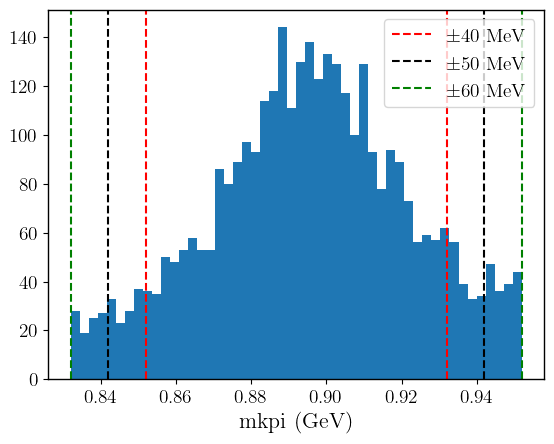

In [2]:
device = "cpu"
n_points = 3000
raw_data, _ = RealData.load_one_file(REAL_DATA / "dataset_bin_8_job_0_0.root", device=device)
print(raw_data[0])
print(raw_data.shape)

Loading LHCb files:   0%|          | 0/40 [00:00<?, ?it/s]

tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3526]), mkpi tensor([0.8898, 0.9106, 0.8689, 0.8807, 0.8847])
tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3534]), mkpi tensor([0.8895, 0.8678, 0.8908, 0.8865, 0.8949])
tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3530]), mkpi tensor([0.8897, 0.8772, 0.9402, 0.8936, 0.8379])
tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3554]), mkpi tensor([0.9212, 0.9391, 0.9140, 0.9013, 0.8904])
tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Siz

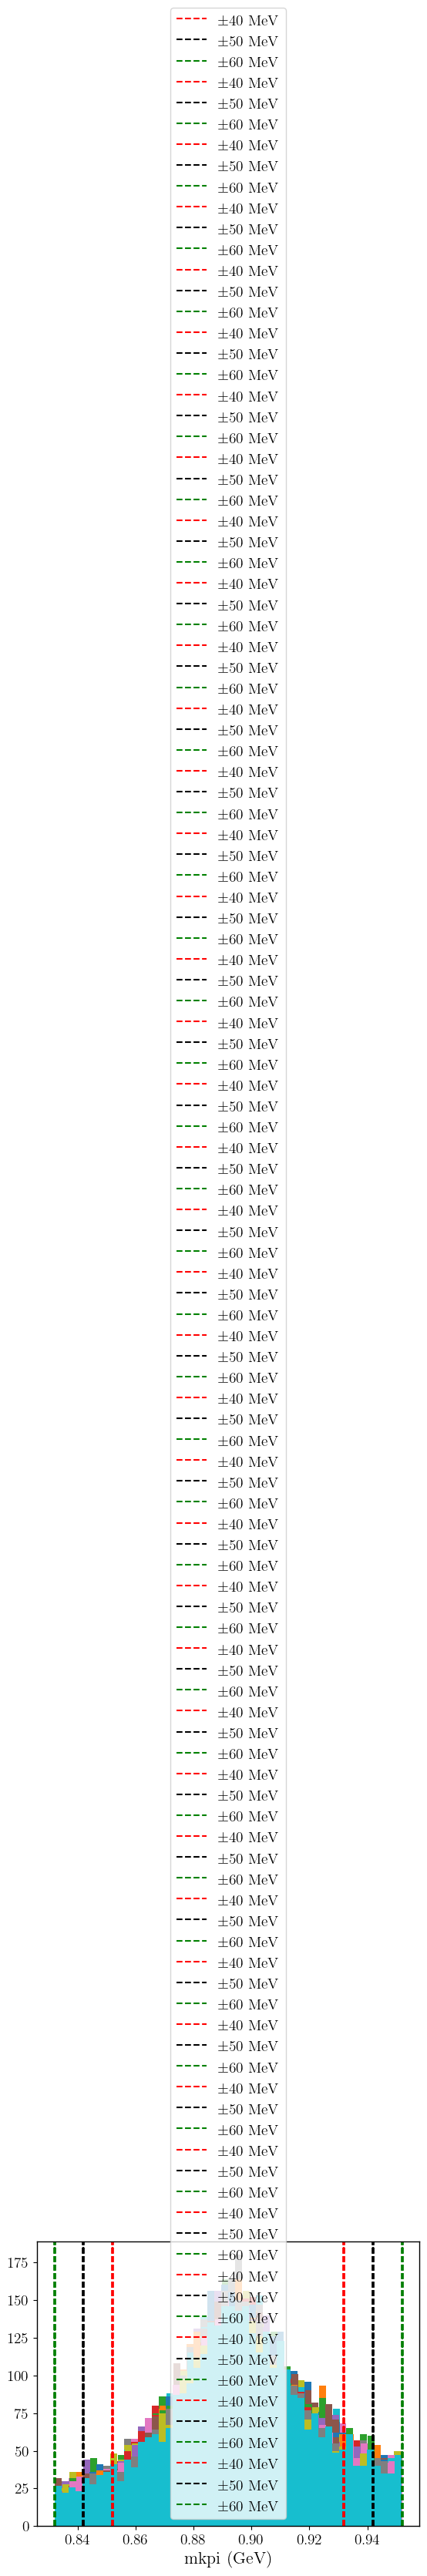

In [3]:
raw_data, _ = RealData.load_whole_directory(REAL_DATA, device)[:n_points]
print(raw_data.shape)
print(f"q2 min and max in the data: {raw_data[:, 0].min().item()}, {raw_data[:, 0].max().item()}")
print(f"mb min and max in the data: {raw_data[:, -1].min().item()}, {raw_data[:, -1].max().item()}")

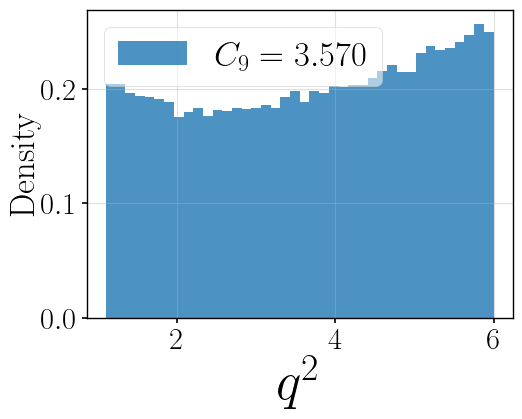

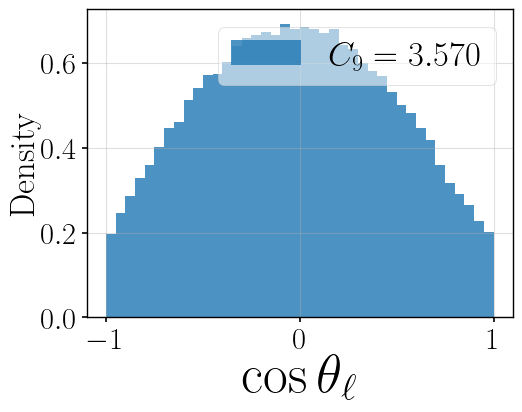

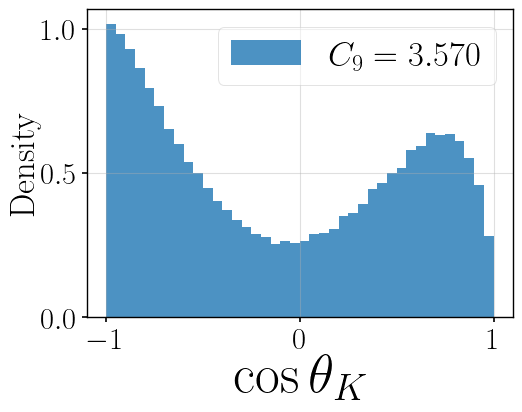

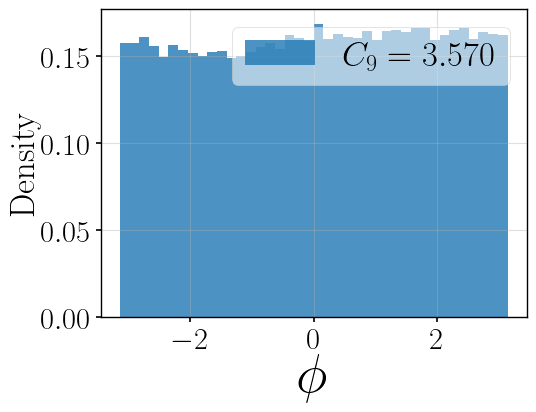

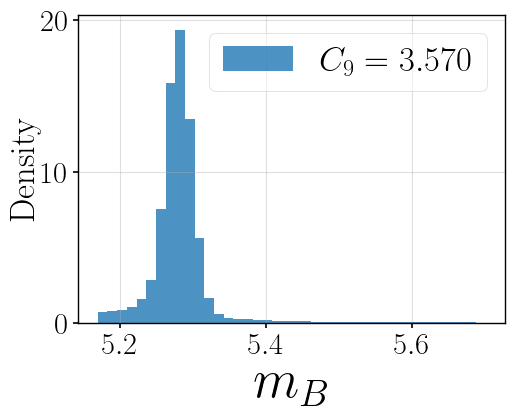

In [4]:
Plotter.plot_a_sample(raw_data, torch.as_tensor(C9, device=device))

In [5]:
model = Model(device, n_points=n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=DEFAULT_STRIDE, pre_N=DEFAULT_PRE_N, preruns=DEFAULT_PRERUNS)
model.set_normalizer_with_data(raw_data=raw_data)
model.build_default()
data = model.normalizer.normalize_data(raw_data)

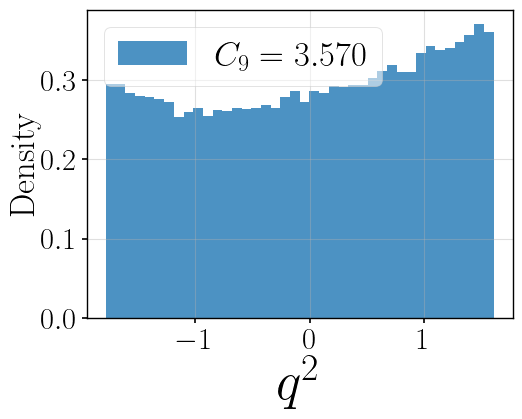

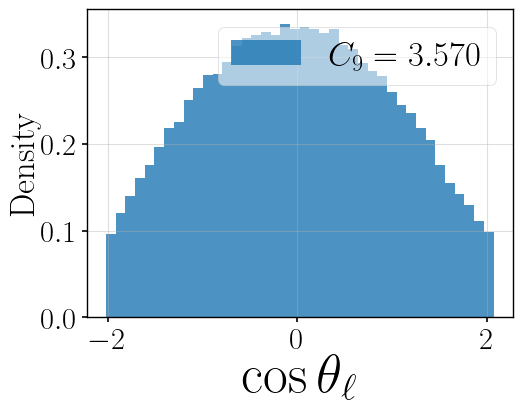

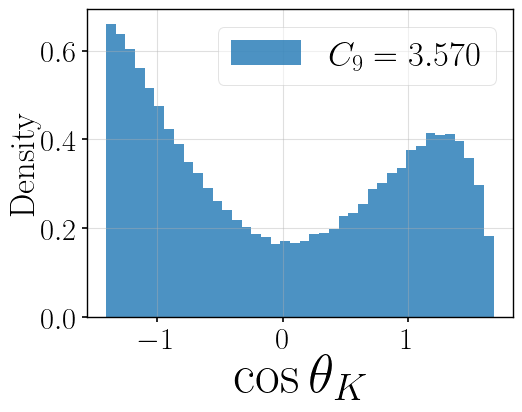

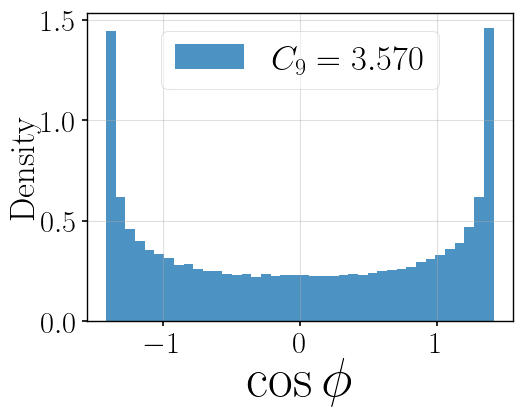

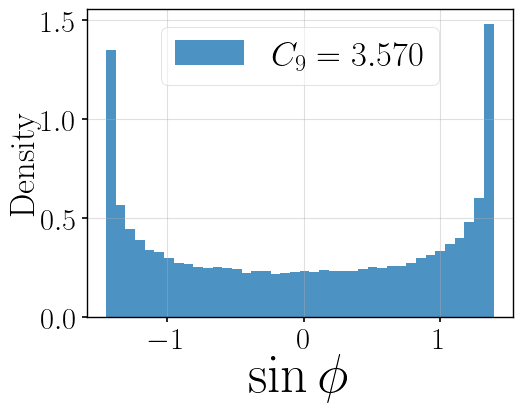

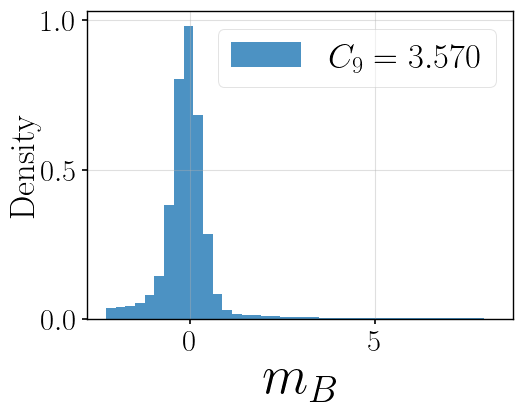

In [6]:
Plotter.plot_a_sample(data, torch.as_tensor(C9, device=device), raw=False)
 # phi is cos phi, because this function is supposed to be called with raw data

In [7]:
print(data.shape)
print(raw_data.shape)
print(data[:,5].mean(), data[:,5].std())
print(raw_data[:,4].mean(), raw_data[:,4].std())
print(model.normalizer.data_mean, model.normalizer.data_std)

torch.Size([140377, 6])
torch.Size([140377, 5])
tensor(-3.3696e-06) tensor(1.0000)
tensor(5.2842) tensor(0.0506)
tensor([ 3.6738e+00, -1.2145e-02, -8.9246e-02,  9.3527e-04,  1.9724e-02,
         5.2842e+00]) tensor([1.4458, 0.4891, 0.6486, 0.7093, 0.7047, 0.0506])


Loading LHCb data (partial):   0%|          | 0/40 [00:00<?, ?it/s]

tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3526]), mkpi tensor([0.8898, 0.9106, 0.8689, 0.8807, 0.8847])
tree branches: ['mB', 'ctl', 'ctk', 'phi', 'mkpi', 'eff', 'weight', 'year', 'pol', 'id', 'q2', 'KmumuVeto', 'KmumuVetoTreated']
mkpi shape torch.Size([3534]), mkpi tensor([0.8895, 0.8678, 0.8908, 0.8865, 0.8949])


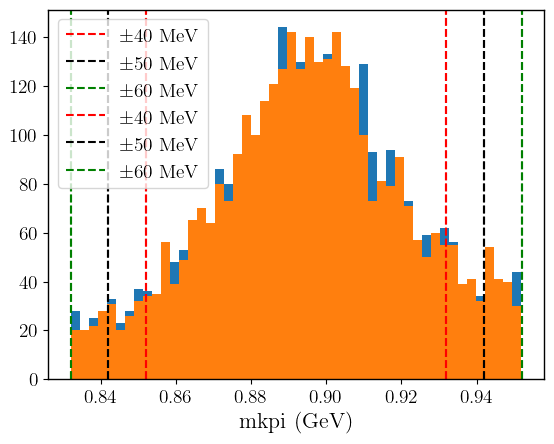

In [8]:
raw_dat, _ = RealData.load_n_points(REAL_DATA, n_points, device=device, ignore_first=n_points+5)

In [9]:
print(raw_data.shape)
print(raw_data[0])

torch.Size([140377, 5])
tensor([ 2.2665,  0.1136, -0.5955,  2.4328,  5.2816])
